In [1]:
import numpy as np
from scipy.optimize import fmin_l_bfgs_b

# --- Physical / model parameters ---
N    = 256        # Number of discretization points
a_M  = 1.0        # Moiré period length, e.g. a_M
a    = 0.5        # Parameter 'a' in the cos(...) term
k    = 1.0        # Stiffness constant 'k'
V0   = 1.0        # Amplitude of the "inter" potential term

In [2]:
def total_energy(u, N, a_M, a, k, V0):
    """
    Compute the discrete approximation of
    E_intra + E_inter, imposing periodic BCs.
    """
    delta_x = a_M / N
    
    # Because of periodicity, we define "shifted" indices with modulo arithmetic.
    # For index n, the neighbors n±1:
    u_plus  = np.roll(u, -1)  # u_{n+1}, with periodic wrap-around
    u_minus = np.roll(u,  1)  # u_{n-1}, with periodic wrap-around
    
    # Intra-layer energy (a discrete approximation of (∂_x u)^2 ).
    # We'll approximate derivative by (u_{n+1} - u_{n-1}) / (2∆x), then square it.
    deriv_sq = ((u_plus - u_minus)/(2*delta_x))**2
    E_intra = 0.5 * k * deriv_sq
    
    # Inter-layer energy:  -2 V0 cos( (2πn / N) + (2π/a)*u_n )
    # We'll define an array for n from 0..N-1
    n_array = np.arange(N)
    E_inter = -2.0 * V0 * np.cos((2.0*np.pi*n_array / N) + (2.0*np.pi/a)*u)
    
    # Sum them up with the factor ∆x
    E_total = np.sum(E_intra + E_inter) * delta_x
    return E_total


In [3]:
def total_energy_grad(u, N, a_M, a, k, V0):
    """
    Compute the gradient (dE/du) for the discrete GSFE model.
    """
    delta_x = a_M / N
    
    # Use roll for periodic boundary conditions
    u_plus  = np.roll(u, -1)    # u_{n+1}
    u_minus = np.roll(u,  1)    # u_{n-1}
    u_plus2 = np.roll(u, -2)    # u_{n+2}
    u_minus2= np.roll(u,  2)    # u_{n-2}

    #---  Intra (derivative wrt u_n):
    # We had E_intra ~ (1/2) k * [ (u_{n+1}-u_{n-1})/(2∆x) ]^2,
    # so d/d u_n E_intra involves terms from u_{n+1}, u_{n-1}, etc.
    # One straightforward approach is to directly use finite differences from eq. (58):
    grad_intra = (k/(4*delta_x)) * (2*u - u_plus2 - u_minus2)
    
    #--- Inter (derivative wrt u_n):
    n_array = np.arange(N)
    argument = (2.0*np.pi*n_array / N) + (2.0*np.pi / a)*u
    grad_inter = (4.0 * np.pi / a) * V0 * np.sin(argument) * delta_x
    
    # Combine and return
    grad_total = grad_intra + grad_inter
    return grad_total


Converged solution?  True
Final energy:  -1.224924953371008


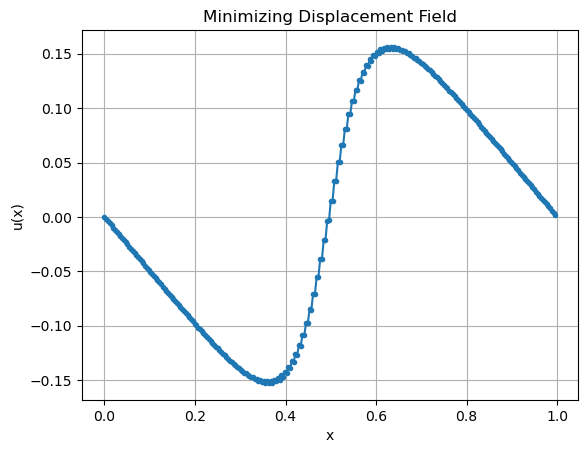

In [4]:
def energy_and_grad(u, *args):
    """
    Wrapper that returns (E, gradE) for the L-BFGS-B optimizer.
    """
    E = total_energy(u, *args)
    g = total_energy_grad(u, *args)
    return E, g


# Initial guess for u
u0 = 0.01 * np.random.randn(N)  # e.g. small random numbers
# Alternatively:
# u0 = np.zeros(N)


# Call the L-BFGS-B solver
result = fmin_l_bfgs_b(
    func=energy_and_grad, 
    x0=u0,
    args=(N, a_M, a, k, V0),
    maxiter=1000,       # or some suitable limit
    factr=1e7,          # controls convergence (~1e7 is moderate)
    pgtol=1e-7          # gradient tolerance
)

u_min, E_min, info = result


print("Converged solution? ", info['warnflag'] == 0)
print("Final energy: ", E_min)

# For example, plot the displacement vs. x:
import matplotlib.pyplot as plt

x_vals = np.linspace(0, a_M, N, endpoint=False)
plt.figure()
plt.plot(x_vals, u_min, '-o', markersize=3)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Minimizing Displacement Field")
plt.grid(True)
plt.show()
